# Data Analysis Assignment Questions

### Customer Analysis

1. Total kitne unique customers hain?
2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
3. Gender ke hisaab se total customers kitne hain?
4. Har age category ki average rating calculate karein.
5. Har gender ki average purchase value calculate karein.
6. Kis country mein sabse zyada customers hain?
7. Har country ki average review rating calculate karein.
8. Har country ka average engagement score nikaalein.
9. Kis age group ki engagement sabse zyada hai?
10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.


In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
data = pd.read_csv('customer_updated_data.csv')
data.head()

,Unnamed: 0,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price
0,0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,2,3,50,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,Male,36,31-40,France,Paris,Swim Goggles,Sports,145.97
3,3,4,78,2025-04-21,3,"Good quality, but could be cheaper.",Olivia Smith,Female,24,18-30,Sweden,Stockholm,Climbing Rope,Sports,410.17
4,4,5,64,2023-07-16,3,"Average experience, nothing special.",Sarah Martinez,Female,62,61-70,Belgium,Brussels,Fitness Tracker,Sports,196.68


In [77]:
data.drop(columns=["Unnamed: 0"], inplace= True)

In [78]:
data.head()

,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price
0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,3,50,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,Male,36,31-40,France,Paris,Swim Goggles,Sports,145.97
3,4,78,2025-04-21,3,"Good quality, but could be cheaper.",Olivia Smith,Female,24,18-30,Sweden,Stockholm,Climbing Rope,Sports,410.17
4,5,64,2023-07-16,3,"Average experience, nothing special.",Sarah Martinez,Female,62,61-70,Belgium,Brussels,Fitness Tracker,Sports,196.68


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ReviewID      1363 non-null   int64  
 1   CustomerID    1363 non-null   int64  
 2   ReviewDate    1363 non-null   object 
 3   Rating        1363 non-null   int64  
 4   ReviewText    1363 non-null   object 
 5   CustomerName  1363 non-null   object 
 6   Gender        1363 non-null   object 
 7   Age           1363 non-null   int64  
 8   Age_Category  1334 non-null   object 
 9   Region        1363 non-null   object 
 10  City          1363 non-null   object 
 11  ProductName   1363 non-null   object 
 12  Category      1363 non-null   object 
 13  Price         1363 non-null   float64
dtypes: float64(1), int64(4), object(9)
memory usage: 149.2+ KB


# Customer Analysis

### 1. Total kitne unique customers hain?

In [80]:
data.CustomerID.nunique()

100

### 2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

In [81]:
bins = [18, 30, 40, 70]

data['Age_Categories']  = pd.cut(data.Age, bins, labels=['Young', 'Adult', 'Senior'])

<Axes: xlabel='Age_Categories', ylabel='count'>

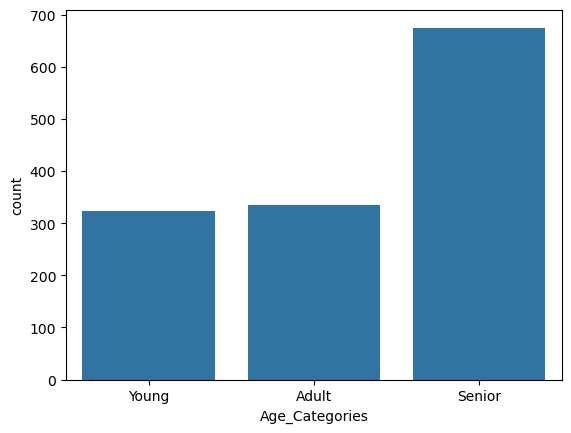

In [82]:
sns.countplot(data, x= 'Age_Categories')

### 3. Gender ke hisaab se total customers kitne hain?

In [83]:
gender = data.Gender.value_counts()
gender

Gender
Female    737
Male      626
Name: count, dtype: int64

<Axes: xlabel='Gender'>

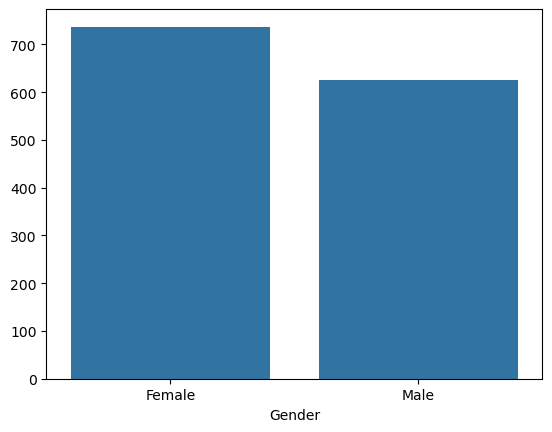

In [84]:
sns.barplot(x= gender.index, y= gender.values)

### 4. Har age category ki average rating calculate karein.

In [85]:
rating_avg = data.groupby('Age_Categories')['Rating'].mean()
rating_avg

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_14168\469639894.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_avg = data.groupby('Age_Categories')['Rating'].mean()


Age_Categories
Young     3.703704
Adult     3.722388
Senior    3.682963
Name: Rating, dtype: float64

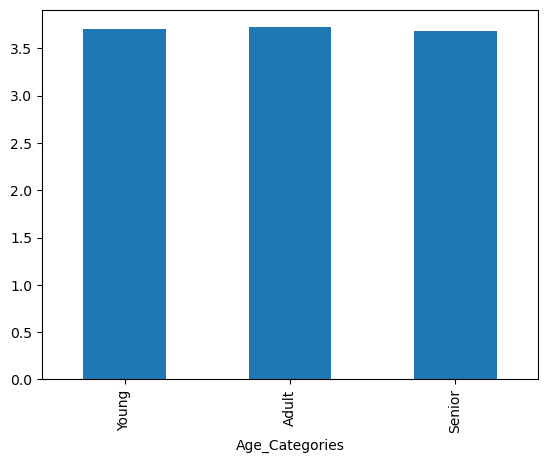

In [86]:
rating_avg.plot(kind='bar')
plt.show()

### 5. Har gender ki average purchase value calculate karein.

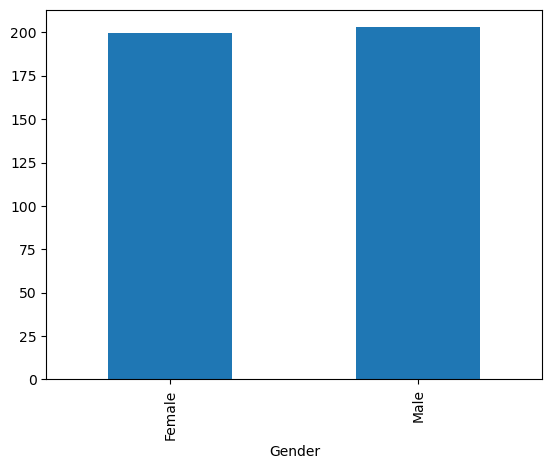

In [87]:
purchase_avg = data.groupby('Gender')['Price'].mean()
purchase_avg.plot(kind= 'bar')
plt.show()

### 6. Kis country mein sabse zyada customers hain?

In [88]:
data.Region.value_counts().index[0]

'Spain'

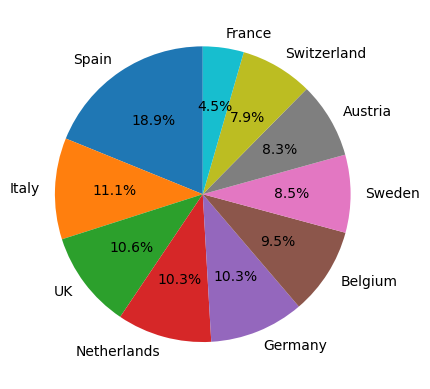

In [95]:
plt.pie(data.Region.value_counts(), labels= data.Region.value_counts().index, autopct= '%1.1f%%', startangle= 90)
plt.show()

### 7. Har country ki average review rating calculate karein.

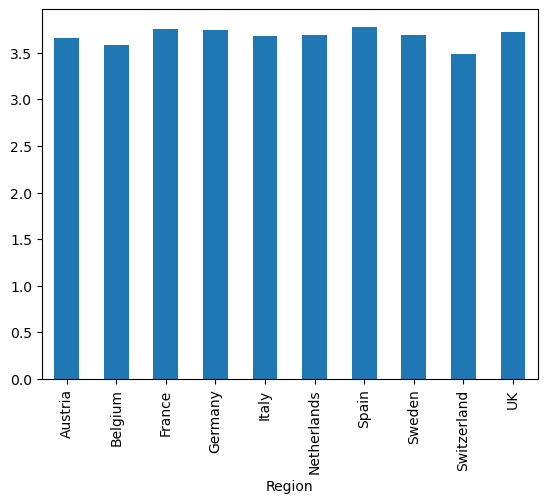

In [99]:
data.groupby('Region')['Rating'].mean().plot(kind='bar')
plt.show()

### 8. Har country ka average engagement score nikaalein.

### 9. Kis age group ki engagement sabse zyada hai?

### 10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

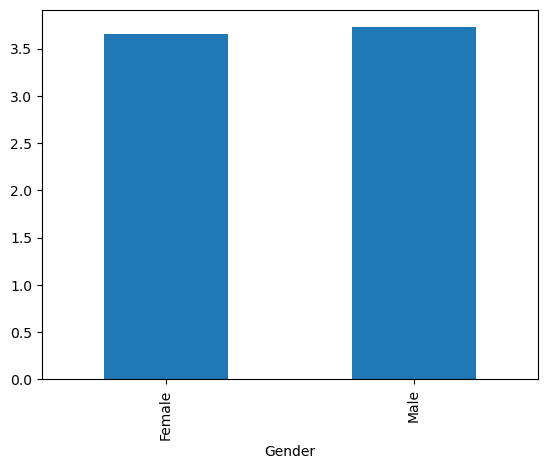

In [105]:
data.groupby('Gender')['Rating'].mean().plot(kind='bar')
plt.show()

#### Insight:
- Graph ko dekh kar yeh pata chalta hai ke Male aur Female customers ki average ratings mein koi bada ya khass farq nahi hai (dono ki average rating lagbhag barabar hai, jo ke $3.5$ ke paas hai).
- Iska matlab hai ke dono genders aapke products se ek jaisa hi satisfied hain.